In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
channels_dict = {
    "CH_M3_1": 2030, 
    "CH_M3_2": 2031, 
    "CH_M4_1": 2040, 
    "CH_M4_2": 2041, 
    "CH_M5_1": 2050, 
    "CH_M5_2": 2051, 
    "CH_M6_1": 2060, 
    "CH_M6_2": 2061,
    "CH_M7_1": 2070,
    "CH_M7_2": 2071,
    "CH_M8_1": 2080,
    "CH_M8_2": 2081
}

# Use 1 if one ADC sample corresponds to one timestamp tick.
# Keep the coincidence logic in timestamp units unless you have
# confirmed the timestamp conversion in the decoder source.
SAMPLE_TICKS = 1

# Initial coincidence window, in timestamp ticks.
# If 1 tick = 16 ns, then 125 ticks = 2 us.
COINCIDENCE_WINDOW_TICKS = 40

def baseline(waveform):
    """Calculate the baseline of a waveform."""
    return np.mean(waveform[0:300])

def signal_amplitude(waveform):
    waveform = np.asarray(waveform)
    signal_region = waveform[30:130]
    return np.max(signal_region) - np.min(signal_region)

def signal_peak_tick(waveform):
    waveform = np.asarray(waveform)
    signal_region = waveform[30:130]
    return 30 + int(np.argmax(signal_region))

def noise_rms(waveform):
    """Calculate the RMS of the noise in a waveform."""
    return np.std(waveform[0:300])

def preSignalAmplitude(waveform):
    """Calculate the pre-signal amplitude of a waveform."""
    return np.max(waveform[0:300]) - np.min(waveform[0:300])

def postSignalAmplitude(waveform):
    """Calculate the post-signal amplitude of a waveform."""
    return np.max(waveform[350:1023]) - np.min(waveform[350:1023])

def Waveforms_Coincidence_byAmplitude(waveform_1, waveform_2, timestamp_1, timestamp_2, threshold):
    """Check if two waveforms are in coincidence based on amplitude threshold."""
    amp1 = signal_amplitude(waveform_1)
    amp2 = signal_amplitude(waveform_2)
    tick_amp1 = signal_peak_tick(waveform_1)
    tick_amp2 = signal_peak_tick(waveform_2)


    if amp1 > threshold and amp2 > threshold and abs(tick_amp1 - tick_amp2) <= COINCIDENCE_WINDOW_TICKS and timestamp_1 == timestamp_2:
        return True
    else:
        return False

In [4]:
channels_forCoincidenceLeft = np.array(list(channels_dict.values(   )), dtype=int)[:4]
channels_forCoincidenceRight = np.array(list(channels_dict.values(   )), dtype=int)[4:8]
channels_toSaveWF = np.array(list(channels_dict.values(   )), dtype=int)[-4:]
channels_forCoincidence = np.array(list(channels_dict.values(   )), dtype=int)[0:8]
print(channels_forCoincidence, channels_forCoincidenceLeft, channels_forCoincidenceRight,channels_toSaveWF)

[2030 2031 2040 2041 2050 2051 2060 2061] [2030 2031 2040 2041] [2050 2051 2060 2061] [2070 2071 2080 2081]


In [5]:
channels_toSaveWF_dict = {k: v for i, (k, v) in enumerate(channels_dict.items()) if i >= len(channels_dict) - 4}
print(channels_toSaveWF_dict)

{'CH_M7_1': 2070, 'CH_M7_2': 2071, 'CH_M8_1': 2080, 'CH_M8_2': 2081}


In [6]:
f_inroot = ROOT.TFile.Open("coincident_waveforms_fast_adc_10000_save_adc_3000.root")
tree = f_inroot.Get("CoincidentWaveforms")

tree.SetBranchStatus("*", 1)
df = ROOT.RDataFrame(tree)

valid_channels = np.array(sorted(channels_toSaveWF_dict.values()), dtype=np.int64)
channel_filter = " || ".join(f"saved_channel == {int(ch)}" for ch in valid_channels)

print(channel_filter)
arr = (
    df.Filter(channel_filter)
      .AsNumpy(["event", "saved_channel", "saved_waveform_index", "adc"])
)

events = arr["event"].astype(np.int64, copy=False)
wf = arr["adc"]
wf_index = arr["saved_waveform_index"].astype(np.int64, copy=False)
channel_arr = arr["saved_channel"].astype(np.int64, copy=False)

print(f"Total waveforms collected: {len(events)}")


saved_channel == 2070 || saved_channel == 2071 || saved_channel == 2080 || saved_channel == 2081
Total waveforms collected: 1284


Unique waveforms: 644 / 1284


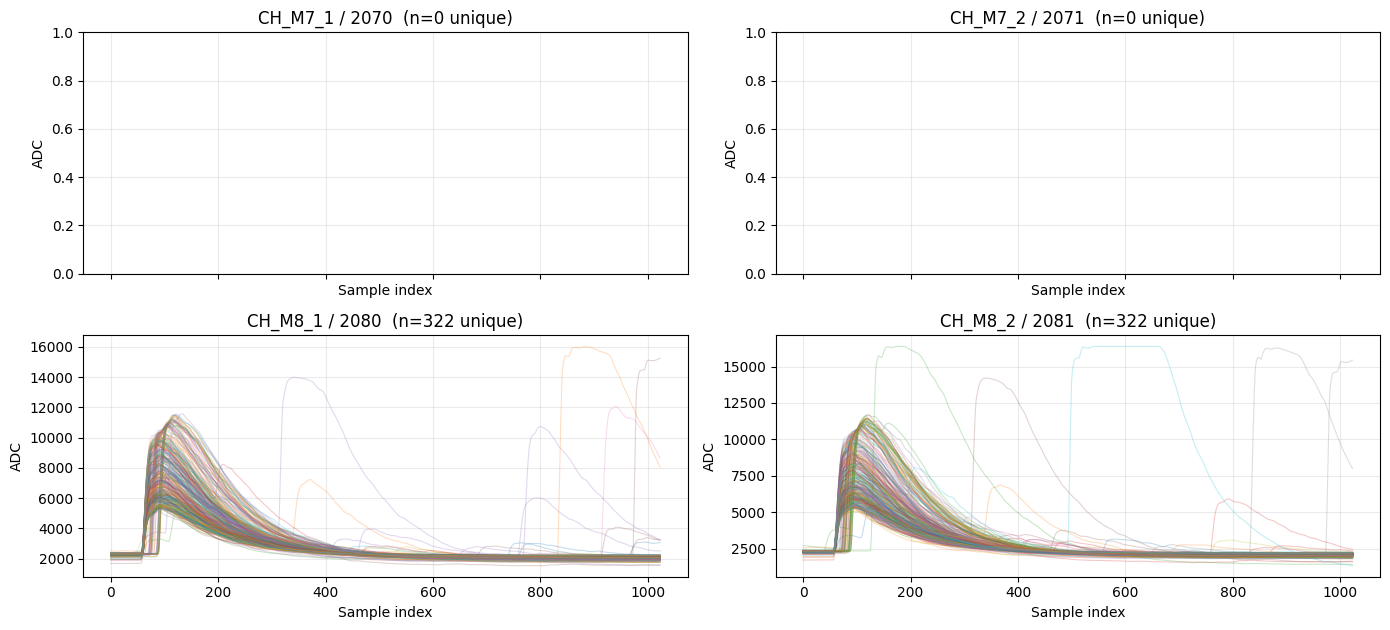

In [7]:
# Plot all unique saved waveforms per channel

channel_name = {v: k for k, v in channels_toSaveWF_dict.items()}

# Unique waveform identity in the coincidence file
keys = np.rec.fromarrays(
    [events, channel_arr, wf_index],
    names=["event", "channel", "wf_index"],
)

_, unique_pos = np.unique(keys, return_index=True)
unique_pos = np.sort(unique_pos)

print(f"Unique waveforms: {len(unique_pos)} / {len(events)}")

unique_counts = {
    ch: int(np.sum(channel_arr[unique_pos] == ch))
    for ch in valid_channels
}

ncols = 2
nrows = int(np.ceil(len(valid_channels) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 3.2 * nrows),
    sharex=True,
)
axes = axes.flatten()

for ax, ch in zip(axes, valid_channels):
    idx = unique_pos[channel_arr[unique_pos] == ch]

    for i in idx:
        y = np.asarray(wf[i], dtype=float)
        x = np.arange(len(y))
        ax.plot(x, y, lw=0.8, alpha=0.25)

    label = channel_name.get(int(ch), f"CH {ch}")
    ax.set_title(f"{label} / {ch}  (n={len(idx)} unique)")
    ax.set_xlabel("Sample index")
    ax.set_ylabel("ADC")
    ax.grid(alpha=0.25)

for ax in axes[len(valid_channels):]:
    ax.axis("off")

plt.tight_layout()
plt.show()